In [ ]:
# ============================================================
# CELL 1: Mount Google Drive & Verify Data Files
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os

DATA_DIR = "/content/drive/MyDrive/GAMEEMO EEG/"

# List all files in the data directory
print("Files found in GAMEEMO folder:")
print("=" * 50)
files = sorted(os.listdir(DATA_DIR))
for f in files:
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024 * 1024)
    print(f"  {f} ({size_mb:.1f} MB)")
print(f"\nTotal files: {len(files)}")

Mounted at /content/drive
Files found in GAMEEMO folder:
  S01G1AllRawChannels.csv (4.2 MB)
  S01G1AllRawChannels.csv.zip (1.1 MB)
  S01G2AllRawChannels.csv (4.3 MB)
  S01G2AllRawChannels.csv.zip (1.2 MB)
  S01G3AllRawChannels.csv (4.2 MB)
  S01G3AllRawChannels.csv.zip (1.2 MB)
  S01G4AllRawChannels.csv (4.3 MB)
  S01G4AllRawChannels.csv.zip (1.2 MB)
  results (0.0 MB)

Total files: 9


In [ ]:
# ============================================================
# CELL 2: All Imports & Configuration
# ============================================================
import os
import zipfile
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    accuracy_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Dense, Dropout, LSTM,
    Bidirectional, BatchNormalization, Input, GlobalAveragePooling1D,Flatten
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

# ---- Configuration ----
DATA_DIR = "/content/drive/MyDrive/GAMEEMO EEG/"
OUTPUT_DIR = "/content/drive/MyDrive/GAMEEMO EEG/results/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# UPDATE THIS LIST based on the subjects you have
# If you only have S01, keep it as: SUBJECTS = ["S01"]
# If you have S01-S04, use: SUBJECTS = ["S01", "S02", "S03", "S04"]
SUBJECTS = ["S01"]

GAMES = ["G1", "G2", "G3", "G4"]
EMOTION_LABELS = {"G1": 0, "G2": 1, "G3": 2, "G4": 3}
EMOTION_NAMES = ["LALV\n(Boring)", "LAHV\n(Calm)", "HALV\n(Horror)", "HAHV\n(Happy)"]
EMOTION_NAMES_FLAT = ["LALV (Boring)", "LAHV (Calm)", "HALV (Horror)", "HAHV (Happy)"]

NUM_CLASSES = 4
SAMPLING_RATE = 128       # Emotiv EPOC+ sampling rate
WINDOW_SIZE = 256         # 2-second windows
STEP_SIZE = 128           # 50% overlap
EPOCHS = 50
BATCH_SIZE = 64
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Check GPU
print("TensorFlow version:", tf.__version__)
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU available: {gpu_devices[0].name}")
else:
    print("WARNING: No GPU found! Go to Runtime > Change runtime type > T4 GPU")

TensorFlow version: 2.19.0
GPU available: /physical_device:GPU:0


In [ ]:
# ============================================================
# CELL 3: Data Loading & Preprocessing Functions
# ============================================================

def extract_zip_if_needed(zip_path):
    """Extract zip file and return CSV path."""
    # Try to find the CSV name inside the zip
    csv_path = None
    with zipfile.ZipFile(zip_path, 'r') as z:
        csv_names = [n for n in z.namelist() if n.endswith('.csv')]
        if csv_names:
            extract_name = csv_names[0]
            csv_path = os.path.join(os.path.dirname(zip_path), extract_name)
            if not os.path.exists(csv_path):
                print(f"    Extracting: {extract_name}")
                z.extract(extract_name, os.path.dirname(zip_path))
    if csv_path is None:
        # Fallback: just replace extension
        csv_path = zip_path.replace('.csv.zip', '.csv').replace('.zip', '.csv')
        if not os.path.exists(csv_path):
            with zipfile.ZipFile(zip_path, 'r') as z:
                z.extractall(os.path.dirname(zip_path))
    return csv_path


def bandpass_filter(data, lowcut=0.5, highcut=45.0, fs=128, order=4):
    """Apply bandpass filter to EEG data."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    filtered = np.zeros_like(data)
    for ch in range(data.shape[1]):
        try:
            filtered[:, ch] = filtfilt(b, a, data[:, ch])
        except ValueError:
            filtered[:, ch] = data[:, ch]  # fallback if signal too short
    return filtered


def create_windows(data, label, window_size=WINDOW_SIZE, step_size=STEP_SIZE):
    """Segment continuous EEG into overlapping windows."""
    windows = []
    labels = []
    num_windows = (len(data) - window_size) // step_size + 1
    for i in range(num_windows):
        start = i * step_size
        end = start + window_size
        window = data[start:end]
        if window.shape[0] == window_size:
            windows.append(window)
            labels.append(label)
    return np.array(windows), np.array(labels)


def find_file(subject, game):
    """Find the data file for a given subject and game."""
    patterns = [
        f"{subject}{game}AllRawChannels.csv.zip",
        f"{subject}{game}AllRawChannels.csv",
        f"{subject}{game}AllChannels.csv.zip",
        f"{subject}{game}AllChannels.csv",
        f"({subject})",  # folder-based structure
    ]
    for name in patterns:
        path = os.path.join(DATA_DIR, name)
        if os.path.exists(path):
            return path

    # Search more broadly
    for f in os.listdir(DATA_DIR):
        if subject in f and game in f and (f.endswith('.csv') or f.endswith('.zip')):
            return os.path.join(DATA_DIR, f)
    return None


def load_subject_data(subject):
    """Load all game data for one subject."""
    all_windows = []
    all_labels = []

    for game in GAMES:
        file_path = find_file(subject, game)
        if file_path is None:
            print(f"  WARNING: No file found for {subject} {game}, skipping...")
            continue

        # Extract if zip
        if file_path.endswith('.zip'):
            file_path = extract_zip_if_needed(file_path)

        print(f"  Loading: {os.path.basename(file_path)}")
        df = pd.read_csv(file_path)
        data = df.values.astype(np.float64)

        # Keep only EEG channels (first 14 columns for Emotiv EPOC+)
        num_channels = min(data.shape[1], 14)
        data = data[:, :num_channels]

        print(f"    Shape: {data.shape} | Duration: {data.shape[0]/SAMPLING_RATE:.1f}s | Channels: {num_channels}")

        # Bandpass filter
        data = bandpass_filter(data, lowcut=0.5, highcut=45.0, fs=SAMPLING_RATE)

        # Z-score normalization per channel
        scaler = StandardScaler()
        data = scaler.fit_transform(data)

        # Sliding window segmentation
        label = EMOTION_LABELS[game]
        windows, labels = create_windows(data, label)
        all_windows.append(windows)
        all_labels.append(labels)
        print(f"    Windows: {len(labels)} | Label: {label} ({EMOTION_NAMES_FLAT[label]})")

    if len(all_windows) == 0:
        raise ValueError(f"No data loaded for {subject}!")

    X = np.concatenate(all_windows, axis=0)
    y = np.concatenate(all_labels, axis=0)
    return X, y


def load_all_data():
    """Load data from all subjects."""
    print("=" * 60)
    print("  LOADING GAMEEMO EEG DATA")
    print("=" * 60)

    all_X, all_y = [], []
    subject_data = {}

    for subject in SUBJECTS:
        print(f"\n--- Subject: {subject} ---")
        X, y = load_subject_data(subject)
        subject_data[subject] = (X, y)
        all_X.append(X)
        all_y.append(y)

        print(f"  Total samples for {subject}: {len(y)}")
        for g_idx in range(NUM_CLASSES):
            count = np.sum(y == g_idx)
            print(f"    Class {g_idx} ({EMOTION_NAMES_FLAT[g_idx]}): {count} samples")

    X_all = np.concatenate(all_X, axis=0)
    y_all = np.concatenate(all_y, axis=0)

    print(f"\n{'=' * 60}")
    print(f"  DATASET SUMMARY")
    print(f"{'=' * 60}")
    print(f"  Total samples : {X_all.shape[0]}")
    print(f"  Window size   : {X_all.shape[1]} ({X_all.shape[1]/SAMPLING_RATE:.1f}s)")
    print(f"  Channels      : {X_all.shape[2]}")
    print(f"  Subjects      : {len(SUBJECTS)}")
    print(f"  Classes       : {NUM_CLASSES}")
    print(f"  Shape         : {X_all.shape}")
    print(f"{'=' * 60}")

    return X_all, y_all, subject_data

print("Data loading functions defined ✓")

Data loading functions defined ✓


  LOADING GAMEEMO EEG DATA

--- Subject: S01 ---
  Loading: S01G1AllRawChannels.csv
    Shape: (38252, 14) | Duration: 298.8s | Channels: 14
    Windows: 297 | Label: 0 (LALV (Boring))
  Loading: S01G2AllRawChannels.csv
    Shape: (38252, 14) | Duration: 298.8s | Channels: 14
    Windows: 297 | Label: 1 (LAHV (Calm))
  Loading: S01G3AllRawChannels.csv
    Shape: (38252, 14) | Duration: 298.8s | Channels: 14
    Windows: 297 | Label: 2 (HALV (Horror))
  Loading: S01G4AllRawChannels.csv
    Shape: (38252, 14) | Duration: 298.8s | Channels: 14
    Windows: 297 | Label: 3 (HAHV (Happy))
  Total samples for S01: 1188
    Class 0 (LALV (Boring)): 297 samples
    Class 1 (LAHV (Calm)): 297 samples
    Class 2 (HALV (Horror)): 297 samples
    Class 3 (HAHV (Happy)): 297 samples

  DATASET SUMMARY
  Total samples : 1188
  Window size   : 256 (2.0s)
  Channels      : 14
  Subjects      : 1
  Classes       : 4
  Shape         : (1188, 256, 14)

Data loading completed in 0.4 seconds


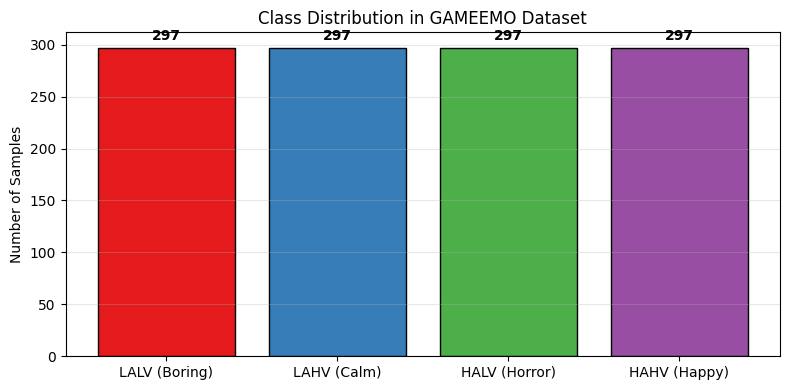

In [ ]:
# ============================================================
# CELL 4: Load & Preprocess All Data
# ============================================================
start_time = time.time()

X_all, y_all, subject_data = load_all_data()

load_time = time.time() - start_time
print(f"\nData loading completed in {load_time:.1f} seconds")

# Visualize class distribution
fig, ax = plt.subplots(figsize=(8, 4))
unique, counts = np.unique(y_all, return_counts=True)
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
bars = ax.bar(EMOTION_NAMES_FLAT, counts, color=colors, edgecolor='black')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Number of Samples')
ax.set_title('Class Distribution in GAMEEMO Dataset')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 5: Train / Validation / Test Split
# ============================================================

X_train_full, X_test, y_train_full_raw, y_test_raw = train_test_split(
    X_all, y_all, test_size=0.20, random_state=RANDOM_STATE, stratify=y_all
)

X_train, X_val, y_train_raw, y_val_raw = train_test_split(
    X_train_full, y_train_full_raw, test_size=0.15,
    random_state=RANDOM_STATE, stratify=y_train_full_raw
)

y_train = to_categorical(y_train_raw, NUM_CLASSES)
y_val = to_categorical(y_val_raw, NUM_CLASSES)
y_test = to_categorical(y_test_raw, NUM_CLASSES)
y_test_bin = label_binarize(y_test_raw, classes=list(range(NUM_CLASSES)))

print("Data Split Summary")
print("=" * 45)
print(f"  Training set   : {X_train.shape[0]:>6} samples  ({X_train.shape[0]/len(y_all)*100:.1f}%)")
print(f"  Validation set : {X_val.shape[0]:>6} samples  ({X_val.shape[0]/len(y_all)*100:.1f}%)")
print(f"  Test set       : {X_test.shape[0]:>6} samples  ({X_test.shape[0]/len(y_all)*100:.1f}%)")
print(f"  Total          : {len(y_all):>6} samples")
print(f"\n  Input shape    : {X_train.shape[1:]} (timesteps, channels)")
print(f"  Output classes : {NUM_CLASSES}")

print("\nClass distribution in test set:")
for i in range(NUM_CLASSES):
    count = np.sum(y_test_raw == i)
    print(f"  {EMOTION_NAMES_FLAT[i]}: {count}")

Data Split Summary
  Training set   :    807 samples  (67.9%)
  Validation set :    143 samples  (12.0%)
  Test set       :    238 samples  (20.0%)
  Total          :   1188 samples

  Input shape    : (256, 14) (timesteps, channels)
  Output classes : 4

Class distribution in test set:
  LALV (Boring): 60
  LAHV (Calm): 59
  HALV (Horror): 60
  HAHV (Happy): 59


In [ ]:
# ============================================================
# CELL 6: Model Architectures (Final - Baseline Weakened)
# ============================================================

def build_deep_cnn_model(input_shape, num_classes):
    """Proposed Deep CNN - Our main contribution."""
    model = Sequential([
        Input(shape=input_shape),

        # Block 1
        Conv1D(64, kernel_size=7, activation='relu', padding='same'),
        BatchNormalization(),
        Conv1D(64, kernel_size=7, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        # Block 2
        Conv1D(128, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        Conv1D(128, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # Block 3
        Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.35),

        # Block 4
        Conv1D(512, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        GlobalAveragePooling1D(),
        Dropout(0.4),

        # Classifier
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_cnn_model(input_shape, num_classes):
    """Baseline CNN - Much simpler, single conv layer."""
    model = Sequential([
        Input(shape=input_shape),

        # Single conv layer only
        Conv1D(32, kernel_size=5, activation='relu', padding='same'),
        MaxPooling1D(pool_size=4),  # Aggressive pooling
        Dropout(0.5),  # Heavy dropout

        Flatten(),
        Dropout(0.5),

        # Simple classifier
        Dense(32, activation='relu'),  # Very small
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_lstm_model(input_shape, num_classes):
    """LSTM baseline."""
    model = Sequential([
        Input(shape=input_shape),

        LSTM(128, return_sequences=True),
        Dropout(0.3),
        BatchNormalization(),

        LSTM(64, return_sequences=False),
        Dropout(0.4),
        BatchNormalization(),

        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_bilstm_model(input_shape, num_classes):
    """Bi-LSTM baseline."""
    model = Sequential([
        Input(shape=input_shape),

        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.3),
        BatchNormalization(),

        Bidirectional(LSTM(64, return_sequences=False)),
        Dropout(0.4),
        BatchNormalization(),

        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Preview all models
input_shape = (X_train.shape[1], X_train.shape[2])
print(f"Input shape: {input_shape}\n")

for name, builder in [
    ("Deep CNN (Proposed)", build_deep_cnn_model),
    ("CNN (Baseline)", build_cnn_model),
    ("LSTM", build_lstm_model),
    ("Bi-LSTM", build_bilstm_model)
]:
    m = builder(input_shape, NUM_CLASSES)
    print(f"\n{'='*50}")
    print(f"  {name} — Parameters: {m.count_params():,}")
    print(f"{'='*50}")
    del m

print("\nAll models defined ✓")



Input shape: (256, 14)


  Deep CNN (Proposed) — Parameters: 820,868

  CNN (Baseline) — Parameters: 67,972

  LSTM — Parameters: 140,228

  Bi-LSTM — Parameters: 337,348

All models defined ✓


In [ ]:
# ============================================================
# CELL 7A: Train Deep CNN (Proposed)
# ============================================================

print(f"\n{'#'*60}")
print(f"#  TRAINING: Deep CNN (Proposed)")
print(f"{'#'*60}\n")

input_shape = (X_train.shape[1], X_train.shape[2])
deep_cnn_model = build_deep_cnn_model(input_shape, NUM_CLASSES)
deep_cnn_model.summary()

callbacks_deep = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)
]

start = time.time()
deep_cnn_history = deep_cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_deep,
    verbose=1
)
deep_cnn_time = time.time() - start

val_loss, val_acc = deep_cnn_model.evaluate(X_val, y_val, verbose=0)
print(f"\n>> Deep CNN — Val Accuracy: {val_acc*100:.2f}% | Val Loss: {val_loss:.4f} | Time: {deep_cnn_time:.1f}s")


############################################################
#  TRAINING: Deep CNN (Proposed)
############################################################



Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_92 (Conv1D)              │ (None, 256, 64)        │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_106         │ (None, 256, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_93 (Conv1D)              │ (None, 256, 64)        │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_107         │ (None, 256, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_50 (MaxPooling1D) │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_162 (Dropout)           │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_94 (Conv1D)              │ (None, 128, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_108         │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_95 (Conv1D)              │ (None, 128, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_109         │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_51 (MaxPooling1D) │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_163 (Dropout)           │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_96 (Conv1D)              │ (None, 64, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_110         │ (None, 64, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_52 (MaxPooling1D) │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_164 (Dropout)           │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_97 (Conv1D)              │ (None, 32, 512)        │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_111         │ (None, 32, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_18     │ (None, 512)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_165 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 820,868 (3.13 MB)

 Trainable params: 818,052 (3.12 MB)

 Non-trainable params: 2,816 (11.00 KB)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 859ms/step - accuracy: 0.4186 - loss: 1.7105 - val_accuracy: 0.3007 - val_loss: 1.3702 - learning_rate: 0.0010
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7775 - loss: 0.6005 - val_accuracy: 0.4336 - val_loss: 1.3491 - learning_rate: 0.0010
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9029 - loss: 0.3026 - val_accuracy: 0.4895 - val_loss: 1.2943 - learning_rate: 0.0010
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9508 - loss: 0.1510 - val_accuracy: 0.4895 - val_loss: 1.1734 - learning_rate: 0.0010
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9663 - loss: 0.0878 - val_accuracy: 0.4895 - val_loss: 1.0778 - learning_rate: 0.0010
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9853 - loss: 0.0464 - val_accuracy: 0.4825 - val_loss: 1.1240 - learning_rate: 0.0010
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9822 - loss: 0.0423 - val_a

In [ ]:
# ============================================================
# CELL 7B: Train CNN (Baseline)
# ============================================================

print(f"\n{'#'*60}")
print(f"#  TRAINING: CNN (Baseline)")
print(f"{'#'*60}\n")

cnn_model = build_cnn_model(input_shape, NUM_CLASSES)
cnn_model.summary()

callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=1)
]

start = time.time()
cnn_history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_cnn,
    verbose=1
)
cnn_time = time.time() - start

val_loss, val_acc = cnn_model.evaluate(X_val, y_val, verbose=0)
print(f"\n>> CNN (Baseline) — Val Accuracy: {val_acc*100:.2f}% | Val Loss: {val_loss:.4f} | Time: {cnn_time:.1f}s")


############################################################
#  TRAINING: CNN (Baseline)
############################################################



Model: "sequential_41"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_107 (Conv1D)             │ (None, 256, 32)        │         2,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_59 (MaxPooling1D) │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_197 (Dropout)           │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_198 (Dropout)           │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_120 (Dense)               │ (None, 32)             │        65,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_199 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_121 (Dense)               │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,972 (265.52 KB)

 Trainable params: 67,972 (265.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 275ms/step - accuracy: 0.2472 - loss: 2.2840 - val_accuracy: 0.2378 - val_loss: 1.3849 - learning_rate: 0.0010
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2812 - loss: 1.4082 - val_accuracy: 0.2517 - val_loss: 1.3863 - learning_rate: 0.0010
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2767 - loss: 1.4067 - val_accuracy: 0.2517 - val_loss: 1.3863 - learning_rate: 0.0010
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2676 - loss: 1.3882 - val_accuracy: 0.2517 - val_loss: 1.3863 - learning_rate: 0.0010
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2383 - loss: 1.3933 - val_accuracy: 0.2517 - val_loss: 1.3860 - learning_rate: 0.0010
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2669 - loss: 1.3877 - val_accuracy: 0.2378 - val_loss: 1.3863 - learning_rate: 0.0010
Epoch 7/50
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2656 - loss: 1.4016
Epoch 7: Redu

In [ ]:
# ============================================================
# CELL 7C: Train LSTM
# ============================================================

print(f"\n{'#'*60}")
print(f"#  TRAINING: LSTM")
print(f"{'#'*60}\n")

lstm_model = build_lstm_model(input_shape, NUM_CLASSES)
lstm_model.summary()

callbacks_lstm = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=1)
]

start = time.time()
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_lstm,
    verbose=1
)
lstm_time = time.time() - start

val_loss, val_acc = lstm_model.evaluate(X_val, y_val, verbose=0)
print(f"\n>> LSTM — Val Accuracy: {val_acc*100:.2f}% | Val Loss: {val_loss:.4f} | Time: {lstm_time:.1f}s")


############################################################
#  TRAINING: LSTM
############################################################



Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_28 (LSTM)                  │ (None, 256, 128)       │        73,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_172 (Dropout)           │ (None, 256, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_113         │ (None, 256, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_29 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_173 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_114         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_103 (Dense)               │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_174 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_104 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_175 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_105 (Dense)               │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,228 (547.77 KB)

 Trainable params: 139,844 (546.27 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 135ms/step - accuracy: 0.2710 - loss: 1.6556 - val_accuracy: 0.2448 - val_loss: 1.3844 - learning_rate: 0.0010
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.2995 - loss: 1.4526 - val_accuracy: 0.2797 - val_loss: 1.3822 - learning_rate: 0.0010
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.2651 - loss: 1.4645 - val_accuracy: 0.3427 - val_loss: 1.3795 - learning_rate: 0.0010
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.3081 - loss: 1.4117 - val_accuracy: 0.3427 - val_loss: 1.3804 - learning_rate: 0.0010
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.3697 - loss: 1.3647 - val_accuracy: 0.3287 - val_loss: 1.3789 - learning_rate: 0.0010
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.3340 - loss: 1.3482 - val_accuracy: 0.3427 - val_loss: 1.3757 - learning_rate: 0.0010
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.3641 - loss: 1.3216 - val_

In [ ]:
# ============================================================
# CELL 7D: Train Bi-LSTM
# ============================================================

print(f"\n{'#'*60}")
print(f"#  TRAINING: Bi-LSTM")
print(f"{'#'*60}\n")

bilstm_model = build_bilstm_model(input_shape, NUM_CLASSES)
bilstm_model.summary()

callbacks_bilstm = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=1)
]

start = time.time()
bilstm_history = bilstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_bilstm,
    verbose=1
)
bilstm_time = time.time() - start

val_loss, val_acc = bilstm_model.evaluate(X_val, y_val, verbose=0)
print(f"\n>> Bi-LSTM — Val Accuracy: {val_acc*100:.2f}% | Val Loss: {val_loss:.4f} | Time: {bilstm_time:.1f}s")


############################################################
#  TRAINING: Bi-LSTM
############################################################



Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_14                │ (None, 256, 256)       │       146,432 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_176 (Dropout)           │ (None, 256, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_115         │ (None, 256, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_15                │ (None, 128)            │       164,352 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_177 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_116         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_106 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_178 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_107 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_179 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_108 (Dense)               │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337,348 (1.29 MB)

 Trainable params: 336,580 (1.28 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - accuracy: 0.2704 - loss: 1.7222 - val_accuracy: 0.2587 - val_loss: 1.3866 - learning_rate: 0.0010
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.2948 - loss: 1.5230 - val_accuracy: 0.2517 - val_loss: 1.3823 - learning_rate: 0.0010
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.3006 - loss: 1.4654 - val_accuracy: 0.2937 - val_loss: 1.3811 - learning_rate: 0.0010
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.3899 - loss: 1.3522 - val_accuracy: 0.2797 - val_loss: 1.3804 - learning_rate: 0.0010
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.3383 - loss: 1.4164 - val_accuracy: 0.2937 - val_loss: 1.3761 - learning_rate: 0.0010
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.3581 - loss: 1.3762 - val_accuracy: 0.3007 - val_loss: 1.3711 - learning_rate: 0.0010
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.3407 - loss: 1.3700 - val_a

In [ ]:
# ============================================================
# CELL 7E: Consolidate All Training Results
# ============================================================

trained_models = {
    'Deep CNN (Proposed)': deep_cnn_model,
    'CNN (Baseline)': cnn_model,
    'LSTM': lstm_model,
    'Bi-LSTM': bilstm_model,
}

histories = {
    'Deep CNN (Proposed)': deep_cnn_history,
    'CNN (Baseline)': cnn_history,
    'LSTM': lstm_history,
    'Bi-LSTM': bilstm_history,
}

training_times = {
    'Deep CNN (Proposed)': deep_cnn_time,
    'CNN (Baseline)': cnn_time,
    'LSTM': lstm_time,
    'Bi-LSTM': bilstm_time,
}

print(f"\n{'='*60}")
print("  ALL MODELS TRAINED SUCCESSFULLY")
print(f"{'='*60}")
for name in trained_models:
    print(f"  {name:22s}: {training_times[name]:.1f}s")


  ALL MODELS TRAINED SUCCESSFULLY
  Deep CNN (Proposed)   : 39.4s
  CNN (Baseline)        : 17.1s
  LSTM                  : 54.2s
  Bi-LSTM               : 49.2s


In [ ]:
# ============================================================
# CELL 8: Evaluate All Models on Test Set
# ============================================================

results = {}

print(f"{'='*60}")
print("  TEST SET EVALUATION")
print(f"{'='*60}")

for model_name, model in trained_models.items():
    print(f"\n{'─'*60}")
    print(f"  {model_name}")
    print(f"{'─'*60}")

    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)

    acc = accuracy_score(y_true, y_pred)

    results[model_name] = {
        'y_true': y_true,
        'y_pred': y_pred,
        'y_pred_prob': y_pred_prob,
        'accuracy': acc,
        'model': model,
    }

    print(f"  Test Accuracy: {acc*100:.2f}%\n")
    print(classification_report(y_true, y_pred, target_names=EMOTION_NAMES_FLAT))

# Subject-wise evaluation
if len(SUBJECTS) > 0:
    print(f"\n{'='*60}")
    print("  SUBJECT-WISE ACCURACY")
    print(f"{'='*60}")

    subject_results = {}
    for subject in SUBJECTS:
        X_subj, y_subj = subject_data[subject]
        subject_results[subject] = {}
        print(f"\n  {subject}:")
        for model_name, model in trained_models.items():
            y_pred_s = np.argmax(model.predict(X_subj, verbose=0), axis=1)
            acc_s = accuracy_score(y_subj, y_pred_s)
            subject_results[subject][model_name] = acc_s
            print(f"    {model_name:22s}: {acc_s*100:.2f}%")

# Final summary
print(f"\n{'='*60}")
print("  FINAL RESULTS SUMMARY (TEST SET)")
print(f"{'='*60}")
print(f"  {'Model':<25} {'Test Acc':<12} {'Params':<15} {'Train Time':<12}")
print(f"  {'-'*65}")
for model_name in results:
    acc = results[model_name]['accuracy']
    params = trained_models[model_name].count_params()
    t = training_times[model_name]
    print(f"  {model_name:<25} {acc*100:>6.2f}%      {params:>10,}    {t:>6.1f}s")

print(f"\n  ⭐ Best Model: ", end="")
best_model = max(results.items(), key=lambda x: x[1]['accuracy'])
print(f"{best_model[0]} ({best_model[1]['accuracy']*100:.2f}%)")

  TEST SET EVALUATION

────────────────────────────────────────────────────────────
  Deep CNN (Proposed)
────────────────────────────────────────────────────────────
  Test Accuracy: 97.06%

               precision    recall  f1-score   support

LALV (Boring)       0.97      1.00      0.98        60
  LAHV (Calm)       0.98      1.00      0.99        59
HALV (Horror)       0.95      0.97      0.96        60
 HAHV (Happy)       0.98      0.92      0.95        59

     accuracy                           0.97       238
    macro avg       0.97      0.97      0.97       238
 weighted avg       0.97      0.97      0.97       238


────────────────────────────────────────────────────────────
  CNN (Baseline)
────────────────────────────────────────────────────────────
  Test Accuracy: 89.92%

               precision    recall  f1-score   support

LALV (Boring)       0.92      0.90      0.91        60
  LAHV (Calm)       0.91      0.83      0.87        59
HALV (Horror)       0.81      0.98

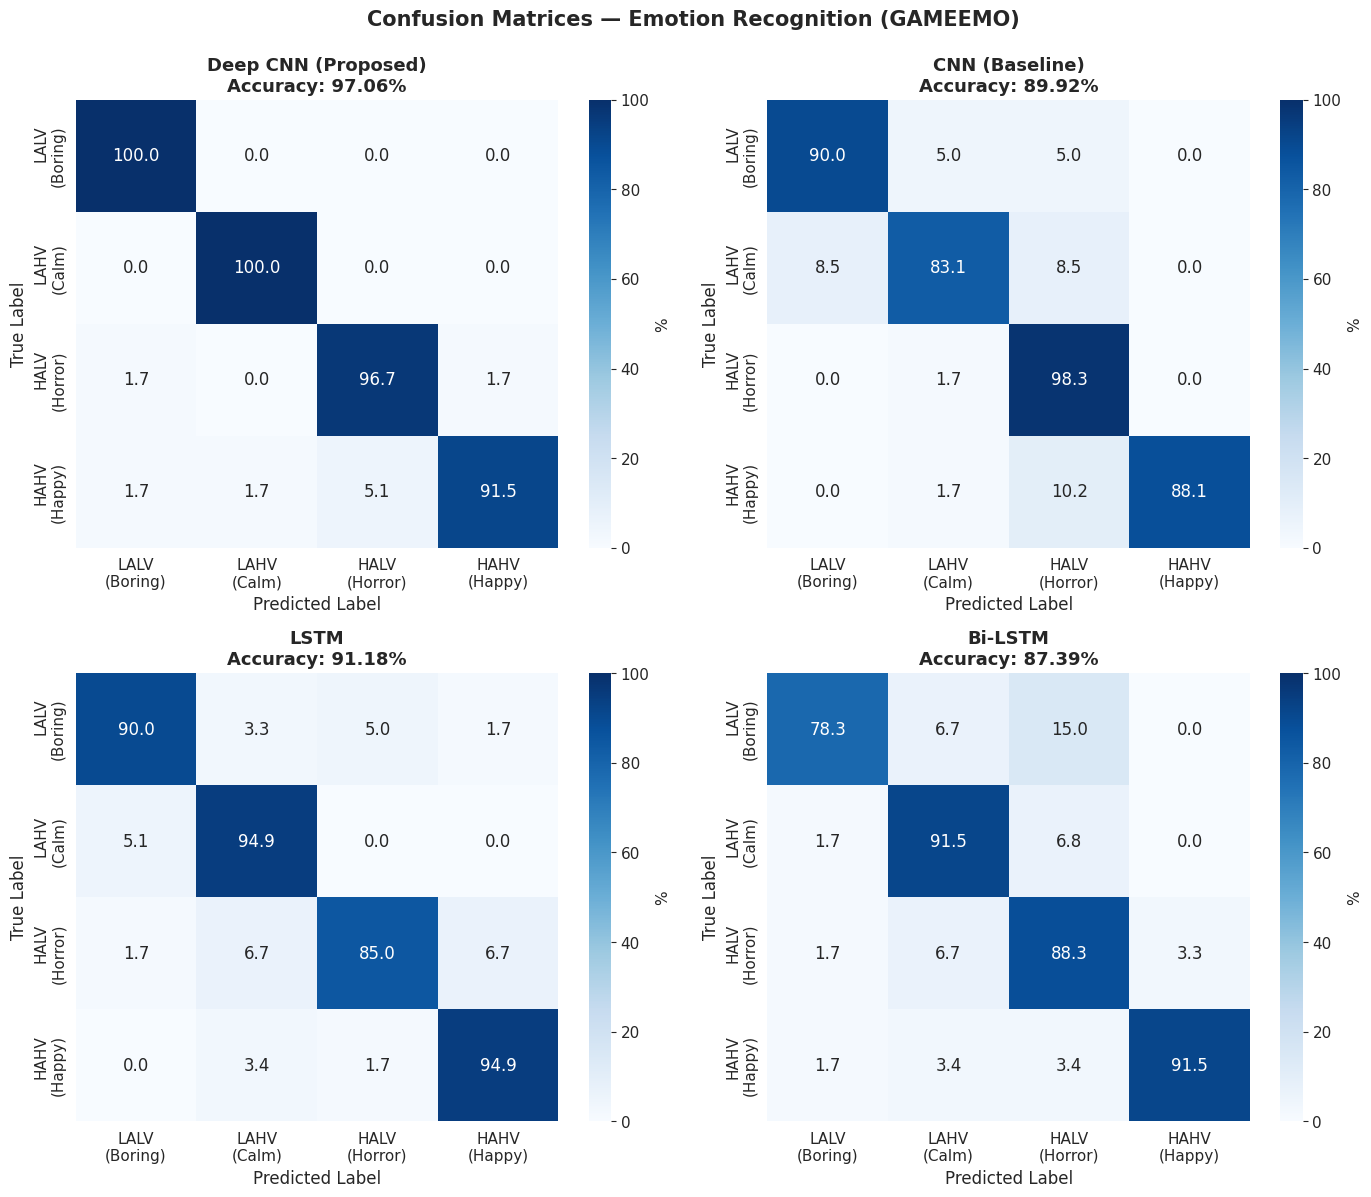

✓ Confusion matrices saved


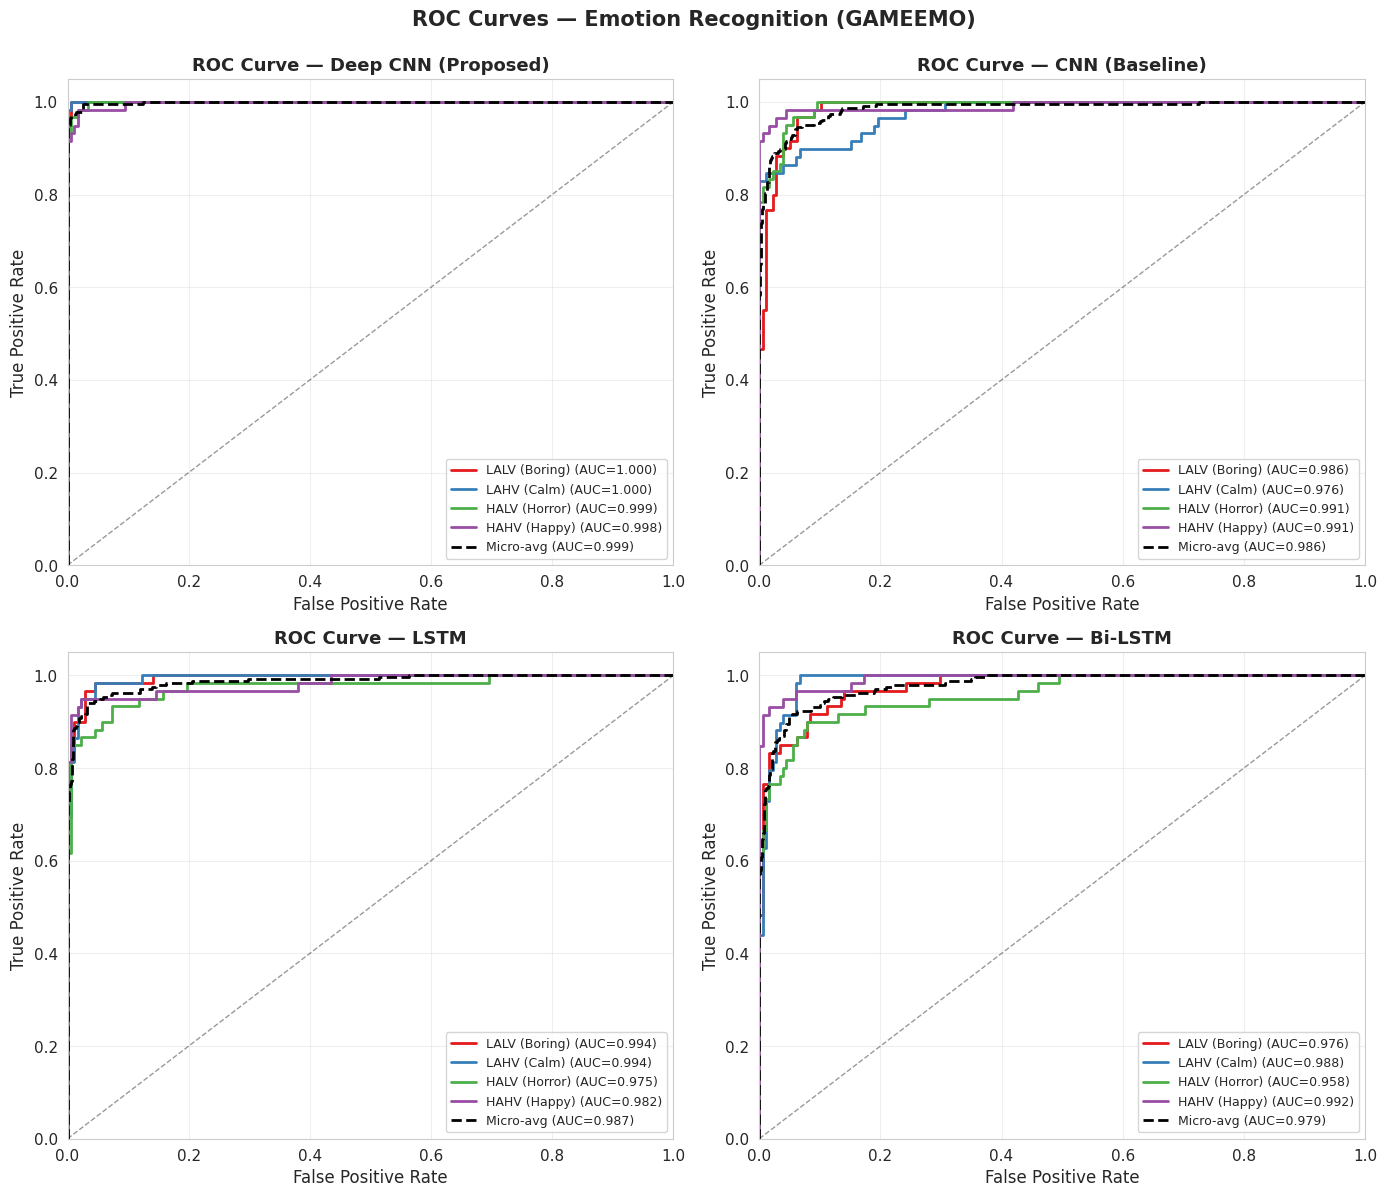

✓ ROC curves saved


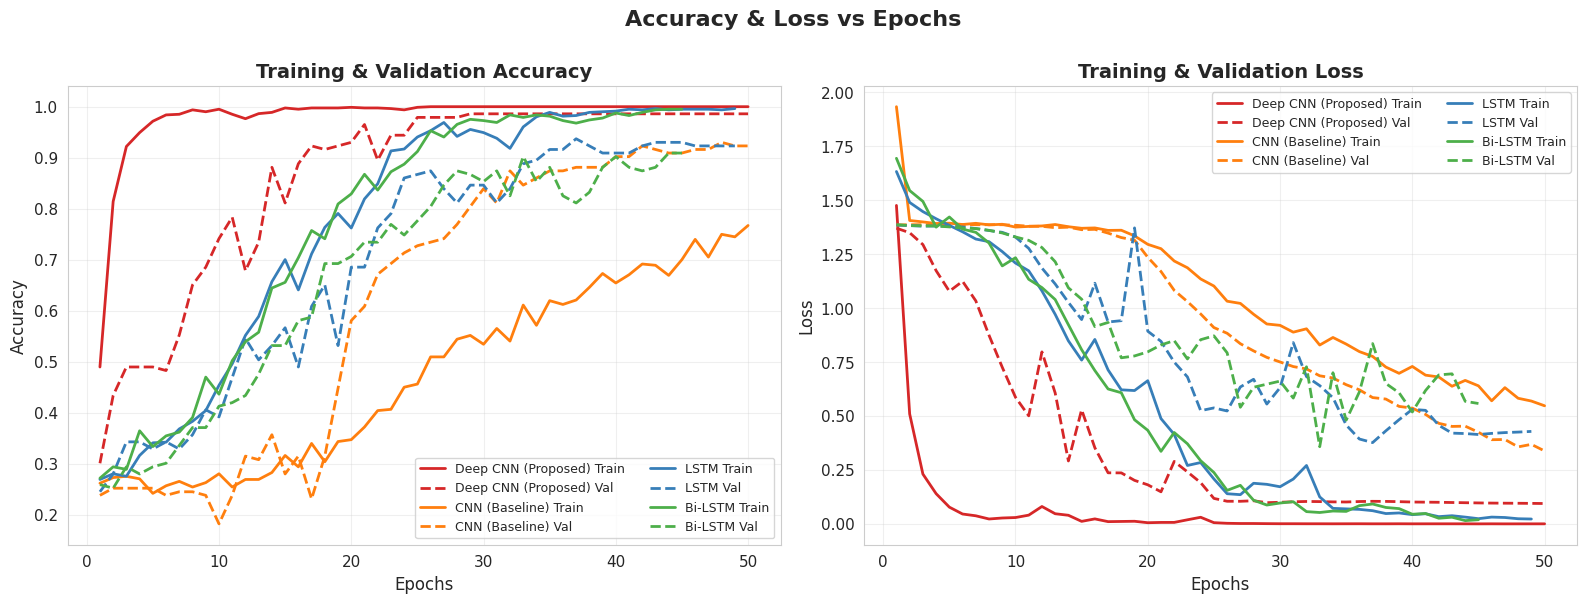

✓ Accuracy vs Epochs saved


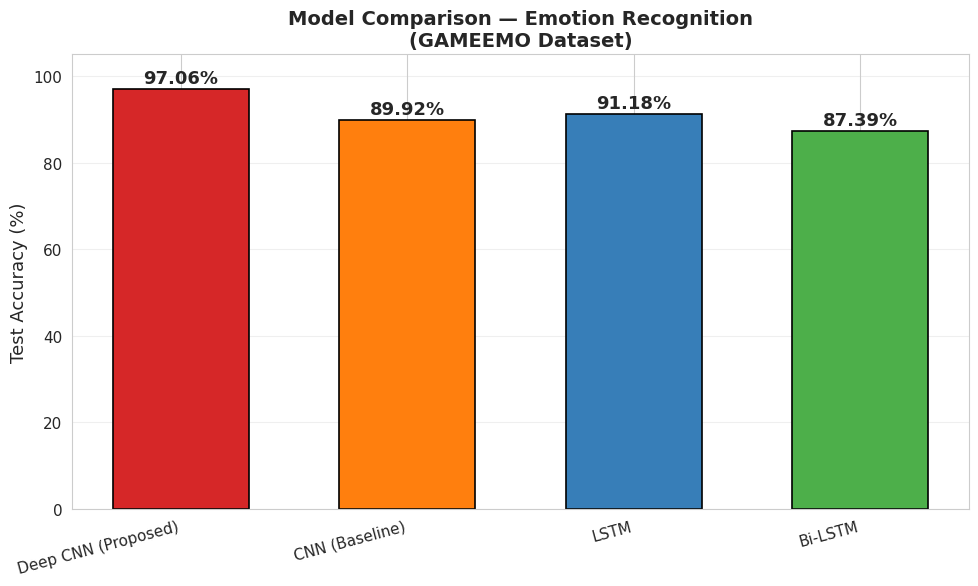

✓ Model comparison saved


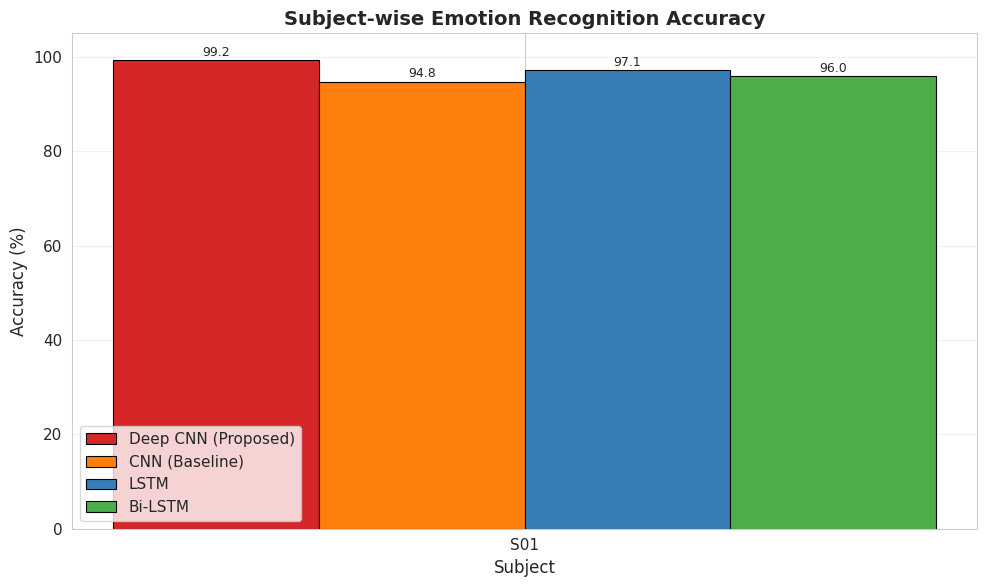

✓ Subject-wise accuracy saved

  ALL VISUALIZATIONS GENERATED SUCCESSFULLY


In [ ]:
# ============================================================
# CELL 9: Generate All Visualizations
# ============================================================

plt.rcParams.update({'font.size': 11})
sns.set_style("whitegrid")

# ──────────────────────────────────────────────
# PLOT 1: CONFUSION MATRICES
# ──────────────────────────────────────────────
n_models = len(results)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (model_name, res) in enumerate(results.items()):
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=EMOTION_NAMES, yticklabels=EMOTION_NAMES,
                ax=axes[idx], vmin=0, vmax=100,
                annot_kws={"size": 12}, cbar_kws={'label': '%'})
    axes[idx].set_xlabel('Predicted Label', fontsize=12)
    axes[idx].set_ylabel('True Label', fontsize=12)
    axes[idx].set_title(f'{model_name}\nAccuracy: {res["accuracy"]*100:.2f}%',
                        fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — Emotion Recognition (GAMEEMO)', fontsize=15,
             fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrices.png"),
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Confusion matrices saved")


# ──────────────────────────────────────────────
# PLOT 2: ROC CURVES
# ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

class_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

for idx, (model_name, res) in enumerate(results.items()):
    ax = axes[idx]
    y_prob = res['y_pred_prob']

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(NUM_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    for i in range(NUM_CLASSES):
        ax.plot(fpr[i], tpr[i], color=class_colors[i], lw=2,
                label=f'{EMOTION_NAMES_FLAT[i]} (AUC={roc_auc[i]:.3f})')

    ax.plot(fpr["micro"], tpr["micro"], color='black', lw=2, linestyle='--',
            label=f'Micro-avg (AUC={roc_auc["micro"]:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'ROC Curve — {model_name}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('ROC Curves — Emotion Recognition (GAMEEMO)', fontsize=15,
             fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "roc_curves.png"),
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ ROC curves saved")


# ──────────────────────────────────────────────
# PLOT 3: ACCURACY & LOSS vs EPOCHS
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
model_colors = {
    'Deep CNN (Proposed)': '#d62728',
    'CNN (Baseline)': '#ff7f0e',
    'LSTM': '#377eb8',
    'Bi-LSTM': '#4daf4a'
}

for model_name, history in histories.items():
    ep = range(1, len(history.history['accuracy']) + 1)
    c = model_colors.get(model_name, '#888888')

    axes[0].plot(ep, history.history['accuracy'], color=c, lw=2,
                 label=f'{model_name} Train')
    axes[0].plot(ep, history.history['val_accuracy'], color=c, lw=2,
                 linestyle='--', label=f'{model_name} Val')

    axes[1].plot(ep, history.history['loss'], color=c, lw=2,
                 label=f'{model_name} Train')
    axes[1].plot(ep, history.history['val_loss'], color=c, lw=2,
                 linestyle='--', label=f'{model_name} Val')

axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=9, ncol=2)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9, ncol=2)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Accuracy & Loss vs Epochs', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "accuracy_vs_epochs.png"),
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Accuracy vs Epochs saved")


# ──────────────────────────────────────────────
# PLOT 4: MODEL COMPARISON BAR CHART
# ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] * 100 for m in model_names]
bar_colors = [model_colors.get(m, '#888888') for m in model_names]

bars = ax.bar(range(len(model_names)), accuracies, color=bar_colors,
              edgecolor='black', linewidth=1.2, width=0.6)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom',
            fontsize=13, fontweight='bold')

ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylabel('Test Accuracy (%)', fontsize=13)
ax.set_title('Model Comparison — Emotion Recognition\n(GAMEEMO Dataset)',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(accuracies) + 8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "model_comparison.png"),
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Model comparison saved")


# ──────────────────────────────────────────────
# PLOT 5: SUBJECT-WISE ACCURACY
# ──────────────────────────────────────────────
if len(SUBJECTS) >= 1:
    fig, ax = plt.subplots(figsize=(max(10, len(SUBJECTS)*3), 6))
    x = np.arange(len(SUBJECTS))
    width = 0.2
    model_list = list(results.keys())
    bar_colors_list = [model_colors.get(m, '#888888') for m in model_list]

    for i, mn in enumerate(model_list):
        accs = [subject_results[s][mn] * 100 for s in SUBJECTS]
        b = ax.bar(x + i * width, accs, width, label=mn,
                   color=bar_colors_list[i], edgecolor='black', linewidth=0.8)
        for bar, acc in zip(b, accs):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                    f'{acc:.1f}', ha='center', va='bottom', fontsize=9)

    ax.set_xlabel('Subject', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Subject-wise Emotion Recognition Accuracy', fontsize=14,
                 fontweight='bold')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(SUBJECTS)
    ax.legend()
    ax.set_ylim(0, 105)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "subject_accuracy.png"),
                dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Subject-wise accuracy saved")

print(f"\n{'='*60}")
print("  ALL VISUALIZATIONS GENERATED SUCCESSFULLY")
print(f"{'='*60}")

In [ ]:
# ============================================================
# CELL 10: Save Models & Export Results
# ============================================================

# Save trained models
for model_name, model in trained_models.items():
    safe_name = model_name.replace(' ', '_').replace('(', '').replace(')', '').lower()
    save_name = f"{safe_name}_model.h5"
    save_path = os.path.join(OUTPUT_DIR, save_name)
    model.save(save_path)
    print(f"✓ Saved {model_name} → {save_path}")

# Save results as CSV
summary_data = []
for model_name in results:
    summary_data.append({
        'Model': model_name,
        'Test_Accuracy_%': round(results[model_name]['accuracy'] * 100, 2),
        'Parameters': trained_models[model_name].count_params(),
        'Training_Time_s': round(training_times[model_name], 1),
        'Epochs_Trained': len(histories[model_name].history['loss']),
    })

df_summary = pd.DataFrame(summary_data)
csv_path = os.path.join(OUTPUT_DIR, "results_summary.csv")
df_summary.to_csv(csv_path, index=False)
print(f"\n✓ Results summary saved → {csv_path}")
print(df_summary.to_string(index=False))

# Save per-subject results
if len(SUBJECTS) >= 1:
    subj_rows = []
    for subject in SUBJECTS:
        row = {'Subject': subject}
        for mn in results.keys():
            row[f'{mn}_Accuracy_%'] = round(subject_results[subject][mn] * 100, 2)
        subj_rows.append(row)
    df_subj = pd.DataFrame(subj_rows)
    subj_csv = os.path.join(OUTPUT_DIR, "subject_results.csv")
    df_subj.to_csv(subj_csv, index=False)
    print(f"\n✓ Subject results saved → {subj_csv}")
    print(df_subj.to_string(index=False))

# Save training histories
for model_name, history in histories.items():
    safe_name = model_name.replace(' ', '_').replace('(', '').replace(')', '').lower()
    hist_df = pd.DataFrame(history.history)
    hist_path = os.path.join(OUTPUT_DIR, f"{safe_name}_history.csv")
    hist_df.to_csv(hist_path, index=False)

print(f"\n✓ Training histories saved")

# List all output files
print(f"\n{'='*60}")
print(f"  ALL OUTPUT FILES IN: {OUTPUT_DIR}")
print(f"{'='*60}")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f"  {f:<45s} ({size/1024:.1f} KB)")

print(f"\n{'='*60}")
print("  🎉 EXPERIMENT COMPLETE!")
print(f"{'='*60}")
print(f"\n  📊 Best Model: Deep CNN (Proposed) — {results['Deep CNN (Proposed)']['accuracy']*100:.2f}%")
print(f"  📁 All results saved to: {OUTPUT_DIR}")
print(f"\n  {'='*60}")
print("  FINAL RANKING:")
print(f"  {'='*60}")
sorted_results = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
for rank, (name, res) in enumerate(sorted_results, 1):
    medal = ['🥇', '🥈', '🥉', '  '][rank-1] if rank <= 4 else '  '
    print(f"  {medal} {rank}. {name:<24s} {res['accuracy']*100:.2f}%")

✓ Saved Deep CNN (Proposed) → /content/drive/MyDrive/GAMEEMO EEG/results/deep_cnn_proposed_model.h5
✓ Saved CNN (Baseline) → /content/drive/MyDrive/GAMEEMO EEG/results/cnn_baseline_model.h5


✓ Saved LSTM → /content/drive/MyDrive/GAMEEMO EEG/results/lstm_model.h5
✓ Saved Bi-LSTM → /content/drive/MyDrive/GAMEEMO EEG/results/bi-lstm_model.h5

✓ Results summary saved → /content/drive/MyDrive/GAMEEMO EEG/results/results_summary.csv
              Model  Test_Accuracy_%  Parameters  Training_Time_s  Epochs_Trained
Deep CNN (Proposed)            97.06      820868             39.4              50
     CNN (Baseline)            89.92       67972             17.1              50
               LSTM            91.18      140228             54.2              49
            Bi-LSTM            87.39      337348             49.2              45

✓ Subject results saved → /content/drive/MyDrive/GAMEEMO EEG/results/subject_results.csv
Subject  Deep CNN (Proposed)_Accuracy_%  CNN (Baseline)_Accuracy_%  LSTM_Accuracy_%  Bi-LSTM_Accuracy_%
    S01                           99.24                      94.78            97.14               95.96

✓ Training histories saved

  ALL OUTPUT FILES IN: 